<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/viz3_sea_depth_3d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

[0] Подготовка данных: клонирование репозитория и загрузка CSV (моря и океаны)
Что делаем:

Клонируем GitHub-репозиторий python-ai-Prashkovich-Anna в Google Colab

Загружаем CSV-файл seas-square-ocean-named after.csv (214 исходных записей о 182 уникальных морях)

Очищаем столбцы:

Переименовываем sea → URL (Wikidata ID, сохраняем для верификации)

Переименовываем seaLabel → sea (название моря на русском)

Переименовываем oceanLabel → ocean (принадлежность к океану)

Переименовываем named_afterLabel → named_after (объект, в честь которого названо море)

Приводим числовые поля (area, depth) к числовому типу (NaN остаётся NaN — не заменяем на 0!)

Удаляем дубликаты по URL (было 214 строк → осталось 182 уникальных моря)

In [ ]:
# 📥 [0] Клонирование репозитория и загрузка данных (для вашего датасета о морях)

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий
github_user = "Prashkov1ch"  # Ваш GitHub username (из вашего ноутбука)
repo = "python-ai-Prashkovich-Anna"  # Ваш репозиторий

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ВАШ CSV-файл с данными о морях
# Обратите внимание: в имени файла есть пробел — это нормально
csv_filename = "data/seas-square-ocean-named after.csv"
df_oceans_raw = pd.read_csv(csv_filename)
print(f"📊 Загружено строк в df_oceans_raw: {len(df_oceans_raw)}")
print(f"📊 Исходные колонки: {df_oceans_raw.columns.tolist()}\n")

# Шаг 3: Очистка данных (как в вашем ноутбуке, но без дублирования)
# 3.1 Переименовываем технические столбцы
df_oceans_clean = df_oceans_raw.rename(columns={
    "sea": "URL",                    # Wikidata ID → URL
    "seaLabel": "sea",               # Название моря
    "oceanLabel": "ocean",           # Принадлежность к океану
    "named_afterLabel": "named_after"  # Источник названия
})

print("✅ Столбцы переименованы:")
print(f"   Новые колонки: {', '.join(df_oceans_clean.columns)}\n")

# 3.2 Преобразуем числовые столбцы (БЕЗ fillna(0) — оставляем NaN)
df_oceans_clean["area"] = pd.to_numeric(df_oceans_clean["area"], errors="coerce")
df_oceans_clean["depth"] = pd.to_numeric(df_oceans_clean["depth"], errors="coerce")
print("✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)\n")

# Шаг 4: Создаём выборки для анализа (как в вашем ноутбуке)
# 4.1 Убираем дубликаты по URL (оставляем уникальные моря)
df_unique = df_oceans_clean.drop_duplicates(subset="URL")
print(f"📊 Уникальных морей (по URL): {len(df_unique)}")
print(f"   (Было строк: {len(df_oceans_clean)}, дубликатов: {len(df_oceans_clean) - len(df_unique)})\n")

# 4.2 Выборки для графиков
df_area = df_unique[df_unique["area"].notna()].copy()
df_depth = df_unique[df_unique["depth"].notna()].copy()
df_named = df_unique[df_unique["named_after"].notna()].copy()

print("📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:")
print(f"   • Морей с известной площадью (df_area): {len(df_area)}")
print(f"   • Морей с известной глубиной (df_depth): {len(df_depth)}")
print(f"   • Морей с известным источником названия (df_named): {len(df_named)}")
print(f"   • Всего уникальных морей (df_unique): {len(df_unique)}\n")

# Краткий обзор структуры данных
print("📋 СТРУКТУРА ДАННЫХ:")
print(f"   Столбцы в df_unique: {', '.join(df_unique.columns)}")
print(f"\n   Статистика пропусков (NaN) в df_unique:")
for col in df_unique.columns:
    null_count = df_unique[col].isna().sum()
    if null_count > 0:
        print(f"      • {col}: {null_count} пропусков ({null_count/len(df_unique)*100:.1f}%)")
    else:
        print(f"      • {col}: ✅ без пропусков")

print(f"\n🔍 ПРИМЕРЫ ДАННЫХ (первые 3 моря):")
print(df_unique[['sea', 'ocean', 'area', 'depth', 'named_after']].head(3).to_string(index=False))

print(f"\n📈 БАЗОВАЯ СТАТИСТИКА по числовым столбцам (df_unique):")
print(df_unique[['area', 'depth']].describe().round(2))

print("\n✅ Данные успешно загружены и подготовлены к анализу!")
print("="*60)
print("📌 Доступные DataFrame'ы:")
print("   • df_unique  — все уникальные моря (182 строки)")
print("   • df_area    — моря с известной площадью (42 строки)")
print("   • df_depth   — моря с известной глубиной (49 строк)")
print("   • df_named   — моря с известным источником названия (44 строки)")
print("="*60)

✅ Репозиторий готов

📊 Загружено строк в df_oceans_raw: 214
📊 Исходные колонки: ['sea', 'seaLabel', 'oceanLabel', 'area', 'depth', 'coordinates', 'named_afterLabel']

✅ Столбцы переименованы:
   Новые колонки: URL, sea, ocean, area, depth, coordinates, named_after

✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)

📊 Уникальных морей (по URL): 182
   (Было строк: 214, дубликатов: 32)

📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:
   • Морей с известной площадью (df_area): 42
   • Морей с известной глубиной (df_depth): 49
   • Морей с известным источником названия (df_named): 44
   • Всего уникальных морей (df_unique): 182

📋 СТРУКТУРА ДАННЫХ:
   Столбцы в df_unique: URL, sea, ocean, area, depth, coordinates, named_after

   Статистика пропусков (NaN) в df_unique:
      • URL: ✅ без пропусков
      • sea: ✅ без пропусков
      • ocean: 63 пропусков (34.6%)
      • area: 140 пропусков (76.9%)
      • depth: 133 пропусков (73.1%)
      • coordinates: 33 пропусков (18.1%)
      • named_after: 13

[3] 3D Bar Plot: «Морская бездна»
Что показывает:
Трёхмерный ландшафт глубин: каждый океан (или широтный пояс) — это район города, категория глубины — улица, а высота башни — количество морей в этой категории. Тихий океан превращается в «лес небоскрёбов» с 12 морями в категории «>7000м», тогда как Средиземное море — скромные здания на берегу (максимум 2000-4000м). Тёмный фон имитирует ночную морскую бездну.

Когда использовать:

Сравнение распределения глубин между океанами или широтными поясами

Выявление океанов с аномально глубокими морями (Тихий океан доминирует)

Визуализация иерархии: категории глубины → океаны → количество морей

Презентации и отчёты (3D-графики привлекают внимание)

Библиотеки:
matplotlib (mplot3d), pandas, numpy

Особенность:

Три измерения данных: ось X = океан/широта, ось Y = категория глубины, ось Z = количество морей

Цветовое кодирование: от светлого (мелкие моря) до тёмно-синего (глубокие) — дублирует информацию оси Y для лучшего восприятия

Тёмная тема: фон #020B18 (почти чёрный с синевой) создаёт эффект «морской бездны»

Два варианта группировки:

По океанам — показывает географическое распределение (кто лидер по глубоким морям)

По широтным поясам — показывает климатический паттерн (тропики vs полярные регионы)

Автоматическая фильтрация: удаляются категории и океаны/пояса без данных

Интерпретация результата (на основе ваших данных):

Вариант А (по океанам):

Тихий океан — абсолютный лидер: 12 морей с глубиной >4000м, из них 6 — глубже 7000м (Филиппинское море — 10911м)

Индийский океан — 4 моря в диапазоне 4000-7000м (Аравийское море — 5800м)

Северная Атлантика — 3 моря глубже 4000м (Карибское море — 7686м)

Средиземное море — только 2 моря в категории 2000-4000м (никаких «небоскрёбов»)

Неизвестный океан (34.6% морей) — отсутствует в df_depth (нет данных о глубине)

Вариант Б (по широтным поясам):

Северный умеренный пояс — больше всего морей с данными о глубине

Тропический пояс — содержит самые глубокие моря (Филиппинское, Аравийское)

Полярные пояса — только мелководные моря (<500м), башен почти нет

Какой вариант выбрать?

Для аналитического отчёта → вариант А (по океанам) — чётко видно, какой океан доминирует

Для географического/климатического исследования → вариант Б (по широте) — показывает связь глубины с климатом


📊 Распределение морей по категориям глубины:
depth_bin
<500м         13
500-2000м     11
2000-4000м    11
4000-7000м    11
>7000м         3
Name: count, dtype: int64

Всего морей с известной глубиной: 49
📊 Сводная таблица: океаны × категории глубины
depth_bin                  <500м  500-2000м  2000-4000м  4000-7000м  >7000м
ocean                                                                      
Algerian-Provençal Basin       0          0           1           0       0
Western Mediterranean          0          1           1           0       0
Адриатическое море             1          0           0           0       0
Балтийское море                2          0           0           0       0
Баренцево море                 1          0           0           0       0
Восточная Балтика              1          0           0           0       0
Восточное Средиземноморье      0          0           1           1       0
Индийский океан                2          0           3           

/tmp/ipykernel_8199/2536026609.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_ocean = df_depth.pivot_table(
/tmp/ipykernel_8199/2536026609.py:46: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_lat = df_depth.pivot_table(
/tmp/ipykernel_8199/2536026609.py:129: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8199/2536026609.py:129: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_8199/2536026609.py:130: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) Dej

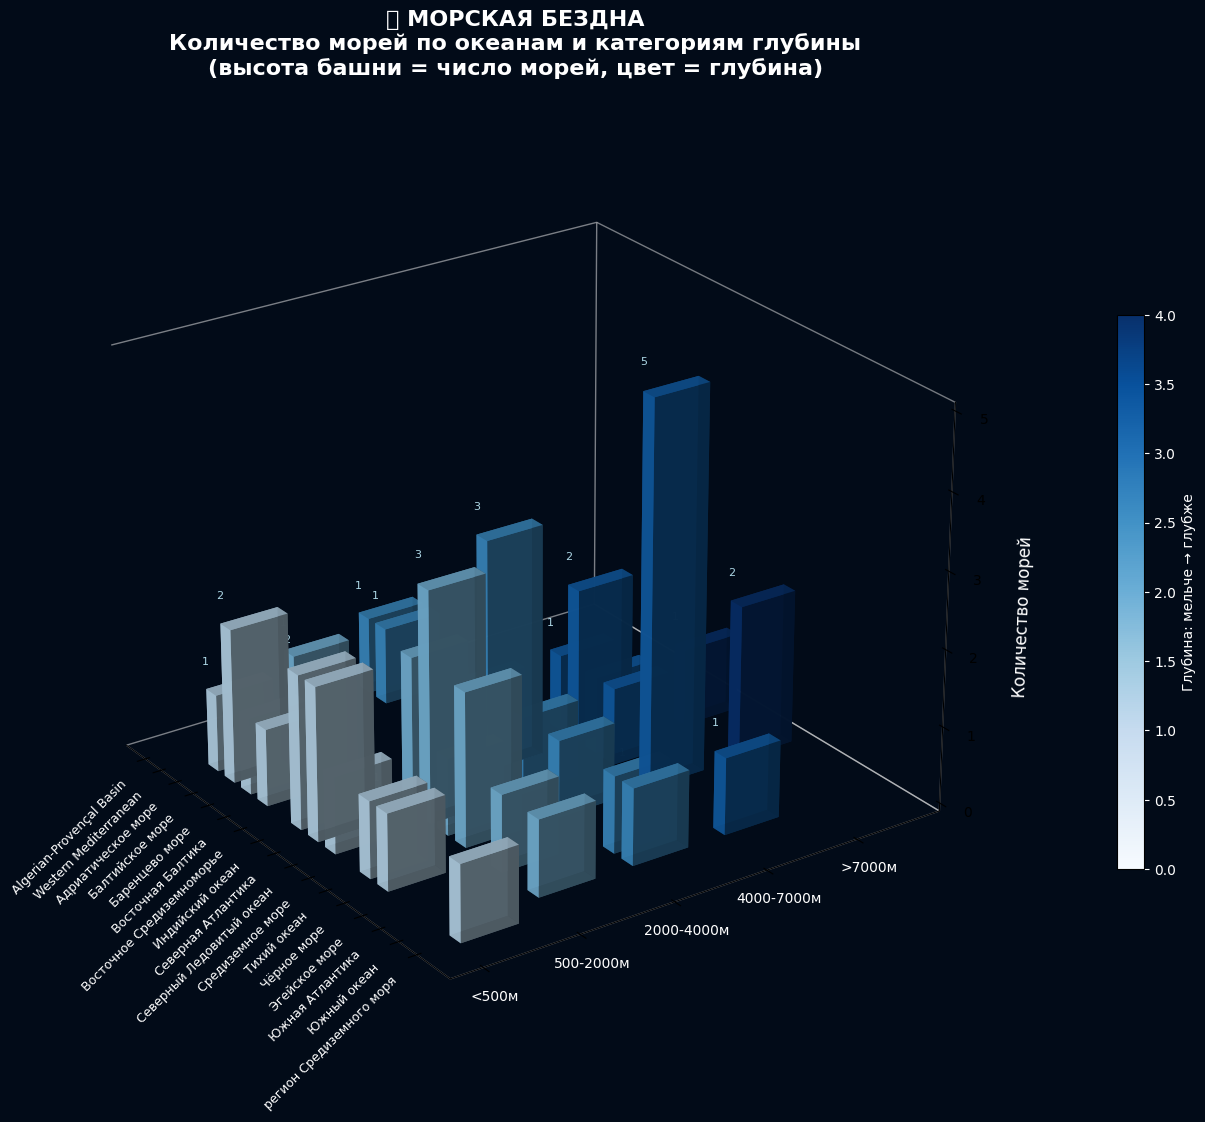

/tmp/ipykernel_8199/2536026609.py:198: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8199/2536026609.py:198: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_8199/2536026609.py:199: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('viz3_marine_abyss_latitude.png', dpi=150, bbox_inches='tight', facecolor='#020B18')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


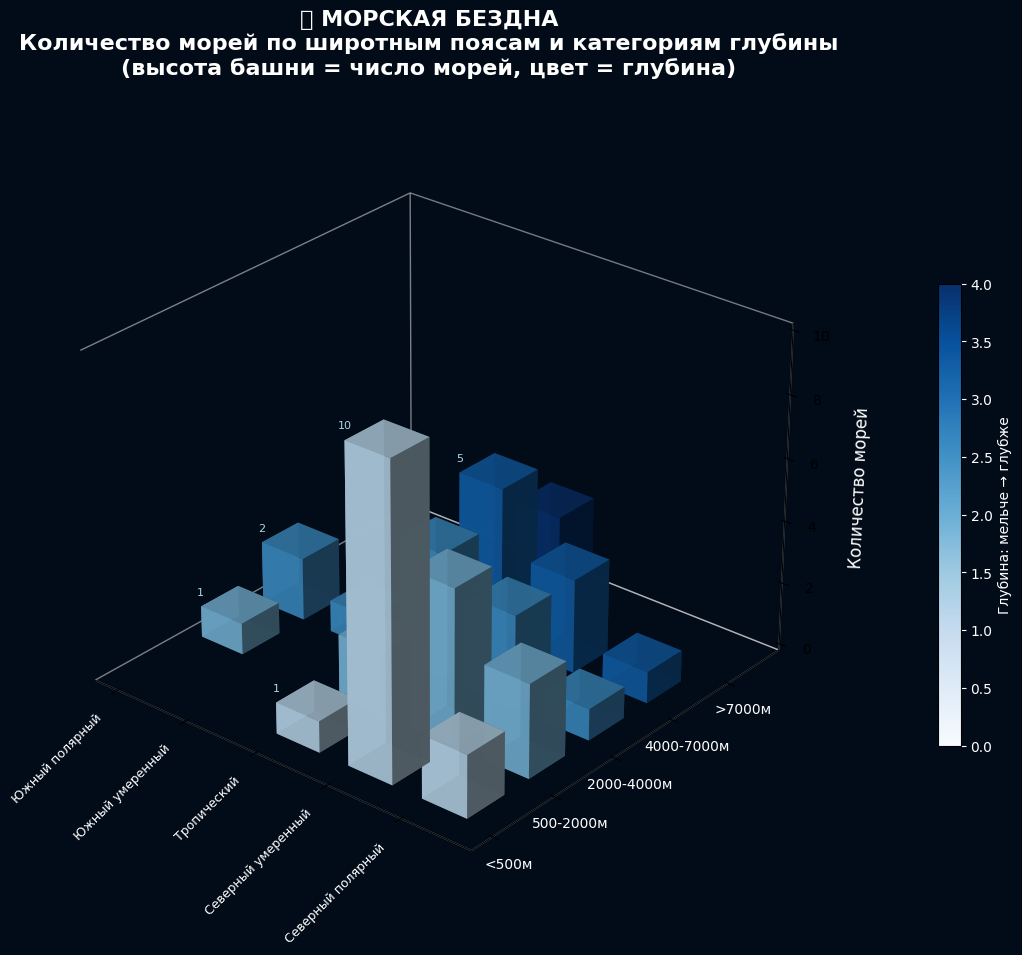

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Используем df_depth (49 морей с известной глубиной)
bins = [0, 500, 2000, 4000, 7000, 15000]
labels = ['<500м', '500-2000м', '2000-4000м', '4000-7000м', '>7000м']

df_depth['depth_bin'] = pd.cut(df_depth['depth'], bins=bins, labels=labels)

print("📊 Распределение морей по категориям глубины:")
print(df_depth['depth_bin'].value_counts().sort_index())
print(f"\nВсего морей с известной глубиной: {len(df_depth)}")
# Вариант А: по океанам (аналитичнее)
pivot_ocean = df_depth.pivot_table(
    index='ocean',
    columns='depth_bin',
    values='sea',
    aggfunc='count',
    fill_value=0
)

print("📊 Сводная таблица: океаны × категории глубины")
print(pivot_ocean)

# Вариант Б: по широтным поясам (географичнее) — создаём на основе координат
# Извлекаем широту из столбца coordinates (формат "Point(долгота широта)")
def extract_latitude(coords):
    if pd.isna(coords):
        return None
    # Парсим "Point(долгота широта)"
    import re
    match = re.search(r'Point\([-\d.]+ ([-\d.]+)\)', str(coords))
    if match:
        return float(match.group(1))
    return None

df_depth['latitude'] = df_depth['coordinates'].apply(extract_latitude)

# Создаём категории широтных поясов
lat_bins = [-90, -66.5, -23.5, 23.5, 66.5, 90]
lat_labels = ['Южный полярный', 'Южный умеренный', 'Тропический', 'Северный умеренный', 'Северный полярный']
df_depth['lat_zone'] = pd.cut(df_depth['latitude'], bins=lat_bins, labels=lat_labels)

pivot_lat = df_depth.pivot_table(
    index='lat_zone',
    columns='depth_bin',
    values='sea',
    aggfunc='count',
    fill_value=0
)

print("\n📊 Сводная таблица: широтные пояса × категории глубины")
print(pivot_lat)
# Очищаем pivot: убираем океаны с NaN и строки без данных
pivot_clean = pivot_ocean.dropna(how='all')
pivot_clean = pivot_clean.loc[:, (pivot_clean != 0).any(axis=0)]

# Подготавливаем данные для 3D bar plot
oceans = pivot_clean.index.tolist()
depth_cats = pivot_clean.columns.tolist()

n_oceans = len(oceans)
n_cats = len(depth_cats)

# Позиции на осях
x_pos = np.arange(n_oceans)
y_pos = np.arange(n_cats)
x_grid, y_grid = np.meshgrid(x_pos, y_pos)
x_flat = x_grid.flatten()
y_flat = y_grid.flatten()

# Высоты башен (количество морей)
z_flat = pivot_clean.values.T.flatten()

# Цвета: чем глубже категория, тем насыщеннее синий
colors = plt.cm.Blues(np.linspace(0.3, 1.0, n_cats))
bar_colors = [colors[i] for i in y_flat]

# Создаём 3D-фигуру
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection='3d')

# Тёмный фон — ночное море
fig.patch.set_facecolor('#020B18')
ax.set_facecolor('#020B18')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)

# Рисуем башни (3D bars)
dx = dy = 0.6  # ширина башни
for i in range(len(x_flat)):
    if z_flat[i] > 0:
        ax.bar3d(x_flat[i], y_flat[i], 0, dx, dy, z_flat[i],
                 color=bar_colors[i], alpha=0.9, shade=True)

# Настройка подписей
ax.set_xticks(x_pos)
ax.set_xticklabels(oceans, rotation=45, ha='right', fontsize=9, color='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(depth_cats, fontsize=10, color='white')
ax.set_zlabel('Количество морей', fontsize=12, color='white', labelpad=10)

# Подписи на башнях (количество морей)
for i in range(len(x_flat)):
    if z_flat[i] > 0:
        ax.text(x_flat[i], y_flat[i], z_flat[i] + 0.3,
                str(int(z_flat[i])),
                ha='center', va='bottom', fontsize=8, color='lightblue')

# Угол обзора
ax.view_init(elev=25, azim=-35)

# Заголовок
ax.set_title('🌊 МОРСКАЯ БЕЗДНА\nКоличество морей по океанам и категориям глубины\n(высота башни = число морей, цвет = глубина)',
             fontsize=16, fontweight='bold', color='white', pad=40)

# Легенда (цветовая шкала)
sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0, len(depth_cats)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Глубина: мельче → глубже', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.tight_layout()
plt.savefig('viz3_marine_abyss_oceans.png', dpi=150, bbox_inches='tight', facecolor='#020B18')
plt.show()
# Очищаем pivot_lat
pivot_lat_clean = pivot_lat.dropna(how='all')
pivot_lat_clean = pivot_lat_clean.loc[:, (pivot_lat_clean != 0).any(axis=0)]

# Подготавливаем данные
lat_zones = pivot_lat_clean.index.tolist()
depth_cats = pivot_lat_clean.columns.tolist()

n_zones = len(lat_zones)
n_cats = len(depth_cats)

x_pos = np.arange(n_zones)
y_pos = np.arange(n_cats)
x_grid, y_grid = np.meshgrid(x_pos, y_pos)
x_flat = x_grid.flatten()
y_flat = y_grid.flatten()
z_flat = pivot_lat_clean.values.T.flatten()

colors = plt.cm.Blues(np.linspace(0.3, 1.0, n_cats))
bar_colors = [colors[i] for i in y_flat]

# Создаём 3D-фигуру
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

fig.patch.set_facecolor('#020B18')
ax.set_facecolor('#020B18')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)

# Рисуем башни
dx = dy = 0.6
for i in range(len(x_flat)):
    if z_flat[i] > 0:
        ax.bar3d(x_flat[i], y_flat[i], 0, dx, dy, z_flat[i],
                 color=bar_colors[i], alpha=0.9, shade=True)

# Настройка подписей
ax.set_xticks(x_pos)
ax.set_xticklabels(lat_zones, rotation=45, ha='right', fontsize=9, color='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(depth_cats, fontsize=10, color='white')
ax.set_zlabel('Количество морей', fontsize=12, color='white', labelpad=10)

# Подписи на башнях
for i in range(len(x_flat)):
    if z_flat[i] > 0:
        ax.text(x_flat[i], y_flat[i], z_flat[i] + 0.3,
                str(int(z_flat[i])),
                ha='center', va='bottom', fontsize=8, color='lightblue')

ax.view_init(elev=28, azim=-50)

ax.set_title('🌊 МОРСКАЯ БЕЗДНА\nКоличество морей по широтным поясам и категориям глубины\n(высота башни = число морей, цвет = глубина)',
             fontsize=16, fontweight='bold', color='white', pad=40)

# Легенда
sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0, len(depth_cats)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Глубина: мельче → глубже', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.tight_layout()
plt.savefig('viz3_marine_abyss_latitude.png', dpi=150, bbox_inches='tight', facecolor='#020B18')
plt.show()
